# 데이터 분석

타이타닉 데이터셋
- 1912년 타이타닉호에 탑승했던 탑승객 중 일부 데이터 (생존여부 포함)를 학습
- 생존에 기여한 데이터 특성을 발견
- 테스트 데이터에 대하여 90% 이상의 정확도로 생존률을 예측하는 머신러닝 모델 개발


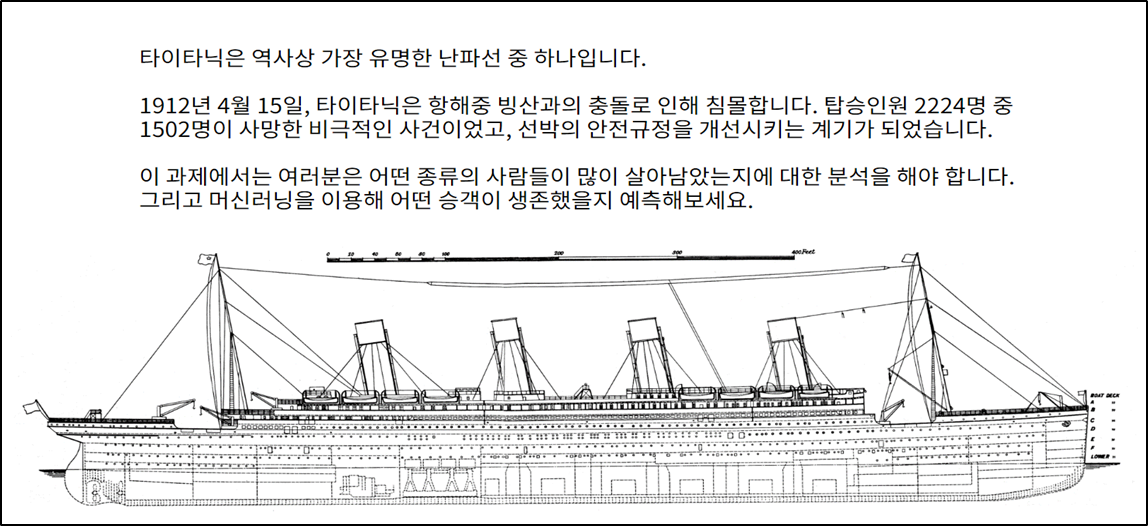

설명 및 데이터 출처:  https://dacon.io/competitions/open/235539/overview/description


### 라이브러리 import

In [38]:
# 행렬 연산 관련
import pandas as pd
import numpy as np

# 데이터 시각화 관련
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set(style = 'white', context = 'notebook', palette = 'deep')

# 경고 무시
import warnings
warnings.filterwarnings('ignore')

# 파일 입출력 관련. 제출 파일 만들때 씀
import glob
import os
# 정규식
import re

import statsmodels.api as sm
from sklearn import preprocessing

# 이미 구현된 인공지능 분류 모델, 학습 기법들
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC


from sklearn.metrics import roc_auc_score, make_scorer
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold, learning_curve

**타이타닉 데이터 분석 준비사항**
- Colab과 Google Drive 활용
- Google drive의 홈에 /KISIA 와 /KISIA/Data - 디렉토리를 생성한다.
- 아래 github에서 test.csv와 train.csv를 다운받아 /KISIA/Data/titanic/에 업로드 한다.
  https://github.com/Harksu71/DataScienceAnalytics/tree/main/data/titanic


## 데이터 준비

### 데이터 로드 및 데이터 프레임화

In [39]:
# 구글 드라이브 마운트
from google.colab import drive ## 코랩에서 구글 드라이브 연동
drive.mount('/content/gdrive')
#설정한 디렉토리에 따라 "/KISIA/Data/" 파트를 조정한다.
#애매하면 "/content/gdrive/My Drive/" 루트에 저장한다.
colab_path = "/content/gdrive/MyDrive/KISIA/Data"


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [40]:
# 데이터 파일 로드 (데이타는 /KISIA/Data/titanic/ 디렉토리에 파일을 업로드 한다)
df_train = pd.read_csv(colab_path + '/train.csv')
df_test = pd.read_csv(colab_path + '/test.csv')
test_y = pd.read_csv(colab_path + '/submission.csv')
test_y = test_y['Survived']
print("학습데이터: {}건, 테스트용 데이터: {}건".format(len(df_train), len(df_test)))

학습데이터: 891건, 테스트용 데이터: 418건


In [41]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


### 데이터 구조 확인

In [42]:
# 데이터 샘플 확인
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [43]:
# 데이터 dimension 확인
df_train.shape

(891, 12)

In [44]:
df_test.shape

(418, 11)

In [45]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [46]:
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [47]:
# 데이터의 개략적인 정보 확인
# df_train.columns
# df_train.dtypes
# df_train.info()
# df_train.describe()

In [103]:
# train, test 전처리 한 번에 하기
dataset = [df_train, df_test] ## 병합
##for data in dataset:
##    data.rename(columns = {'Sex' : 'Gender'}, inplace=True) ## rename
##dataset

In [104]:
# train, test 전처리 한 번에 하기
dataset = [df_train, df_test]
df_alldata = pd.concat(dataset, axis=0)
df_alldata

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_isna
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0.0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0.0
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0.0
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0.0
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,NaN
414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,NaN
415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,NaN
416,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,NaN


In [113]:
df_train.describe(include=["O"])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,891
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,646


In [50]:
sum(df_train['Survived']==0)/len(df_train['Survived'])

0.6161616161616161

### Feature (파생변수, 독립변수)와 Label (Target, 목적변수, 종속변수) 확인

타이타닉 학습용 데이터 (이하 df_train) 에서 최종적으로 예측해야 할 변수는 ‘Survived’ 필드이다.  본 과정에서는 이를 Label이라 지칭하며 Target, 목적변수, 종속변수라도 한다. ‘Survived’를 제외한 나머지 필드는 ML 모델에 사용될 Feature로 활용한다 (파생변수, 독립변수라고도 한다).


‘Survived’의 구성요소 값  0, 1에 대해서는 데이터 description을 참고하여 의미를 확실히 하도록 한다. (0: 사망, 1: 생존) https://www.kaggle.com/datasets/euclidsoft/titianic

#### **About Dataset**
타이타닉 탑승자 명단을 사용하여 타이타닉 데이터 분석 및 생존자 예측

#### **문제 정의하기**
- 타이타닉 탑승자 명단을 통해 생존자 분석 – 디카프리오는 정말 살 수 없었을까?
- 1912년 4월 10일 영국 Southampton에서 출발하고 5일 후, 1912년 4월 15일 침몰
- 이진 분류 예제에 적합한 데이터셋 중 6개 변수, 1개 변수는 생존 결과로 1이면 생존, 0이면 사망
-  6개 변수를 독립변수로 보고 생존 유무를 예측하는 이진 분류 문제로 정의

#### **타이타닉 생존자 예측 데이터 셋 주요 컬럼 설명**
- Survived : 생존 여부 (0 = 사망, 1 = 생존)
- Pclass : 티켓 클래스 (1 = 1등석, 2 = 2등석, 3 = 3등석)
- Sex : 성별
- Age : 나이
- SibSp : 함께 탑승한 자녀 / 배우자 의 수
- Parch : 함께 탑승한 부모님 / 아이들 의 수
- Ticket : 티켓 번호 (동승자는 같은 번호)
- Fare : 탑승 요금 (파운드, 1등실 30파운드, 2등실 12파운드, 3등실 7파운드)
- Cabin : 객실 번호, 첫 글자가 Deck를 의미하며 위치 파악에 활용
객실은 갑판 D부터 갑판 F까지 설치되어 있었다. 흡연실(B 갑판), 식당(D 갑판), 도서관(C 갑판), 상점(E 갑판) 등이 설치되어 있었다.
- Embarked : 선착장 (C = Cherbourg 프랑스, Q = Queenstown 아일랜드, S = Southampton 영국)

In [72]:
# 구성 값 확인
# df_train['Survived'].unique()

# value_counts()는 Series의 unique value를 count해주는 함수
# df_train['Survived'].value_counts()

# value_counts() 결과값을 percent 정보로 변환
(df_train['Survived'].value_counts()/len(df_train)*100).round(2)

,count
Survived,
0,61.62
1,38.38


각 Feature에 대하여 Part 3에서 살펴본 다양한 전처리 기법인 결측치, 이상치, 정규화, 인코딩 처리를 하여 학습데이터를 준비한다.

In [73]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     891 non-null    object 
 12  Age_isna     891 non-null    int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 90.6+ KB


Age, cabin, embarked 결측치 필요

### 결측치 확인

In [74]:
# 결측치 확인
print(df_train.isnull().mean()) #결측치의 개수
print(df_test.isnull().mean()) #결측치의 개수
#df_train.isnull().mean()*100 #결측치를 percentage로 확인

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.000000
Age_isna       0.000000
dtype: float64
PassengerId    0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.205742
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.002392
Cabin          0.782297
Embarked       0.000000
dtype: float64


사용할지 버릴지는 전략. 사용할거면 가공해서 어떻게 써야할지 (cabin같은 경우, 버릴지 가공해서 쓸지)

### 결측치 처리 - Embarked

In [75]:
#train, test 전처리 한번에 하기
dataset = [df_train, df_test] ##병합
df = pd.concat(dataset, axis = 0)
print(len(df))
df.reset_index(drop = True)
## test에는 survived가 없으니까 NaN

1309


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_isna
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0.0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0.0
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0.0
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0.0
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,NaN
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,NaN
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,NaN
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,NaN


In [55]:
df_train['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [56]:
df_train[df_train['Embarked'].isnull()] ## df_train에서 Embarked가 결측치인 승객들의 모든 정보를 보여줌

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


미싱 데이터 -> 가장 밀도가 높은 데이터를 달아주는 전략 좋음

기항지 및 선실 등급별 사망률 비교

In [57]:
df_train.groupby('Embarked')['Pclass'].value_counts() ## 탑승 항구별로 객실 등급 승객이 각각 몇 명인지 계산하는 코드

Embarked  Pclass
C         1          85
          3          66
          2          17
Q         3          72
          2           3
          1           2
S         3         353
          2         164
          1         127
Name: count, dtype: int64

기항지 및 선실 등급별 요금 비교

In [58]:
df_train.groupby(['Pclass','Embarked'])['Fare'].mean() ## groupby는 데이터베이스 함수

Pclass  Embarked
1       C           104.718529
        Q            90.000000
        S            70.364862
2       C            25.358335
        Q            12.350000
        S            20.327439
3       C            11.214083
        Q            11.183393
        S            14.644083
Name: Fare, dtype: float64

In [59]:
df_train['Fare'].describe()

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


In [79]:
df_train[df_train['Fare'] ==  120.0]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_isna
390,391,1,1,"Carter, Mr. William Ernest",male,36.0,1,2,113760,120.0,B96 B98,S,0
435,436,1,1,"Carter, Miss. Lucile Polk",female,14.0,1,2,113760,120.0,B96 B98,S,0
763,764,1,1,"Carter, Mrs. William Ernest (Lucile Polk)",female,36.0,1,2,113760,120.0,B96 B98,S,0
802,803,1,1,"Carter, Master. William Thornton II",male,11.0,1,2,113760,120.0,B96 B98,S,0


In [80]:
df_train['Ticket'].value_counts()

,count
Ticket,
347082,7
1601,7
CA. 2343,7
3101295,6
CA 2144,6
...,...
PC 17590,1
17463,1
330877,1


#### Embarked 결측치는 가장 많이 나온 데이터로 결정

In [81]:
df_train['Embarked'].value_counts(dropna=False) ## embarked

,count
Embarked,
S,646
C,168
Q,77


In [62]:
# 결측치 처리 - Embarked
# 가장 많이 나온 데이터로 대체
# value_counts는 unique값들의 count를 보여주는데, idxmax()로 그 중 가장 많이 나온 데이터를 반환
replace_value = df_train['Embarked'].value_counts(dropna=False).idxmax()
replace_value

'S'

In [83]:
# 결측치 처리(대체) - Embarked
df_train['Embarked'] = df_train['Embarked'].fillna(replace_value) ## null값이 들어간 곳에 S로 채울거임. 복사본 저장해야 함

In [88]:
df_train['Embarked'].isna().sum()

np.int64(0)

In [84]:
df_train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### 결측치 처리 - Age

In [65]:
sum(df_train[df_train['Age'].isna()]['Survived']==1)/177 ## 생존한 사람 수 ?

0.2937853107344633

In [92]:
df_train[df_train['Age'].isna()]['Survived'].mean() ## 나이를 모르니 생존율이 좀 떨어지는 거 같음

np.float64(0.2937853107344633)

In [93]:
# 결측치 처리 - Age
# 추후 Age가 결측치인 데이터를 필터링하여 추가분석 할 수 있도록 Column 생성
df_train['Age_isna'] = df_train['Age'].isna().astype(int) ## 나이가 null인 컬럼 추가. false면 0, true면 1
df_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_isna
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,0


In [105]:
df_train[df_train['Age_isna']==1]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_isna
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,1
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S,1
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C,1
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C,1
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C,1
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S,1
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S,1
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S,1


In [114]:
df_train[df_train['Name'].str.contains('Master')].describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Age_isna
count,40.000000,40.000000,40.000000,36.000000,40.000000,40.000000,40.000000,40.000000
mean,414.975000,0.575000,2.625000,4.574167,2.300000,1.375000,34.703125,0.100000
std,301.717518,0.500641,0.627878,3.619872,1.910833,0.540062,28.051752,0.303822
min,8.000000,0.000000,1.000000,0.420000,0.000000,0.000000,8.516700,0.000000
25%,165.750000,0.000000,2.000000,1.000000,1.000000,1.000000,18.750000,0.000000
50%,345.000000,1.000000,3.000000,3.500000,1.000000,1.000000,29.062500,0.000000
75%,764.000000,1.000000,3.000000,8.000000,4.000000,2.000000,39.171875,0.000000
max,870.000000,1.000000,3.000000,12.000000,8.000000,2.000000,151.550000,1.000000


In [69]:
df_train.describe() ## 전체의 SibSp 평균은 0,52

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Age_isna
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,0.198653
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,0.399210
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,0.000000
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,0.000000
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,0.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000


In [115]:
df_train[df_train['Name'].str.contains('Mrs\.')].describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Age_isna
count,125.000000,125.00000,125.000000,108.000000,125.000000,125.000000,125.000000,125.000000
mean,453.160000,0.79200,2.000000,35.898148,0.696000,0.832000,45.138533,0.136000
std,270.762764,0.40751,0.823055,11.433628,0.598708,1.274666,45.723716,0.344168
min,2.000000,0.00000,1.000000,14.000000,0.000000,0.000000,7.225000,0.000000
25%,255.000000,1.00000,1.000000,27.750000,0.000000,0.000000,15.850000,0.000000
50%,438.000000,1.00000,2.000000,35.000000,1.000000,0.000000,26.000000,0.000000
75%,679.000000,1.00000,3.000000,44.000000,1.000000,1.000000,57.000000,0.000000
max,886.000000,1.00000,3.000000,63.000000,3.000000,6.000000,247.520800,1.000000


In [116]:
df_train[df_train['Name'].str.contains('Mr\.')].describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Age_isna
count,517.000000,517.000000,517.000000,398.000000,517.000000,517.000000,517.000000,517.000000
mean,454.499033,0.156673,2.410058,32.368090,0.288201,0.152805,24.441560,0.230174
std,253.715526,0.363844,0.810622,12.708793,0.821298,0.533615,44.378561,0.421352
min,1.000000,0.000000,1.000000,11.000000,0.000000,0.000000,0.000000,0.000000
25%,226.000000,0.000000,2.000000,23.000000,0.000000,0.000000,7.800000,0.000000
50%,466.000000,0.000000,3.000000,30.000000,0.000000,0.000000,9.350000,0.000000
75%,674.000000,0.000000,3.000000,39.000000,0.000000,0.000000,26.000000,0.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,5.000000,512.329200,1.000000


In [117]:
df_train[df_train['Name'].str.contains('Miss\.')].describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Age_isna
count,182.000000,182.000000,182.000000,146.000000,182.000000,182.000000,182.000000,182.000000
mean,408.884615,0.697802,2.307692,21.773973,0.714286,0.549451,43.797873,0.197802
std,246.775812,0.460477,0.849989,12.990292,1.431961,0.804184,66.027199,0.399441
min,3.000000,0.000000,1.000000,0.750000,0.000000,0.000000,6.750000,0.000000
25%,213.000000,0.000000,1.250000,14.125000,0.000000,0.000000,7.951050,0.000000
50%,381.500000,1.000000,3.000000,21.000000,0.000000,0.000000,15.620850,0.000000
75%,612.250000,1.000000,3.000000,30.000000,1.000000,1.000000,41.034400,0.000000
max,889.000000,1.000000,3.000000,63.000000,8.000000,2.000000,512.329200,1.000000


In [119]:
# df_train을 백업하여 타이틀별 평균 나이로 결측치 대체가 의미 있는지 검토
df_train_TitleAge = df_train

In [120]:
### 만약, 앞에서 다음 부분을 정의해서 실행하면, (학습 타이틀)
### df_train_TitleAge = df_train
### df_train_TitleAge['Title'] = df_train['Name'].apply(lambda x:x.split(',')[1].split('.')[0].strip()) ## 람다 함수 사용
### df_train_TitleAge['Title'].value_conts()
### 실행하면 Title 간의 count 개수 알 수 있음

In [128]:
df_train_TitleAge['Title'] = df_train['Name'].apply(lambda x:x.split(',')[1].split('.')[0].strip()) ## , 로 쪼갬 (왼쪽부터 0번, 오른쪽 1번) .으로 쪼갬 (왼쪽 0번 볼거임)
## strip() 함수는 공백제거
#print(df_train['Title'].isnull().value_counts())
title_age_mean = df_train_TitleAge.groupby('Title')['Age'].mean().to_dict()
title_age_replace_value = df_train_TitleAge['Title'].map(title_age_mean)
df_train_TitleAge['Age'] = df_train_TitleAge['Age'].fillna(title_age_replace_value)


In [129]:
df_train_TitleAge ## title로 Mr, Mrs, Miss.. 추출

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_isna,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S,0,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C,0,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S,0,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S,0,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S,0,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,NaN,S,0,Rev
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S,0,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.773973,1,2,W./C. 6607,23.4500,NaN,S,1,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C,0,Mr


In [133]:
df_train_TitleAge['Title'].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [ ]:
 ## Ms와 Mrs을 넣을 인원 구분하기
# df_train_TitleAge['Title']=df_train_TitleAge['other_Mr'].appyl(lambda x : 'Mr' else df_train_Titleage['Title'])

In [176]:
Major_Titles = ['Mr', 'Mrs', 'Miss', 'Master']
df_train_TitleAge['Title'] = df_train_TitleAge['Title'].apply(lambda x: x if x in Major_Titles else 'Other')
df_train_TitleAge['Title'].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,152
Master,40


In [180]:
df_train_TitleAge.loc[
    (df_train_TitleAge['Title'] == 'Other') & (df_train_TitleAge['Sex']=='male'),
    'Title'
] = 'Mr'

In [178]:
df_train_TitleAge.loc[
    (df_train_TitleAge['Title'] == 'Other') & (df_train_TitleAge['Sex']=='female'),
    'Title'
] = 'Mrs'

In [179]:
df_train_TitleAge['Title'].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,152
Master,40


In [193]:
pclass_fare_mean = df_train.groupby('Pclass')['Fare'].mean().to_dict()
pclass_fare_mean

{1: 84.1546875, 2: 20.662183152173913, 3: 13.675550101832993}

In [194]:
## test 데이터에서 Fare가 Null인 경우, 선실의 등급의 요금 평균을 적용
pclass_fare_mean = df_train.groupby('Pclass')['Fare'].mean().to_dict()
pclass_fare_replace_value = df_test['Pclass'].map(pclass_fare_mean)
df_test['Fare'] = df_test['Fare'].fillna(pclass_fare_replace_value

SyntaxError: incomplete input (749895430.py, line 4)

In [191]:
title_age_mean = df_train.groupby('Title')['Age'].mean().to_dict()
title_age_replace_value = df_train['Title'].map(title_age_mean)
df_train['Age'] = df_train['Age'].fillna(title_age_replace_value)

In [172]:
df_train_TitleAge.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Age_isna', 'Title'],
      dtype='object')

In [181]:
df_train=df_train_TitleAge

In [183]:
df_train[df_train['Title']=='Master']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_isna,Title
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,NaN,S,0,Master
16,17,0,3,"Rice, Master. Eugene",male,2.000000,4,1,382652,29.1250,NaN,Q,0,Master
50,51,0,3,"Panula, Master. Juha Niilo",male,7.000000,4,1,3101295,39.6875,NaN,S,0,Master
59,60,0,3,"Goodwin, Master. William Frederick",male,11.000000,5,2,CA 2144,46.9000,NaN,S,0,Master
63,64,0,3,"Skoog, Master. Harald",male,4.000000,3,2,347088,27.9000,NaN,S,0,Master
65,66,1,3,"Moubarek, Master. Gerios",male,4.574167,1,1,2661,15.2458,NaN,C,1,Master
78,79,1,2,"Caldwell, Master. Alden Gates",male,0.830000,0,2,248738,29.0000,NaN,S,0,Master
125,126,1,3,"Nicola-Yarred, Master. Elias",male,12.000000,1,0,2651,11.2417,NaN,C,0,Master
159,160,0,3,"Sage, Master. Thomas Henry",male,4.574167,8,2,CA. 2343,69.5500,NaN,S,1,Master
164,165,0,3,"Panula, Master. Eino Viljami",male,1.000000,4,1,3101295,39.6875,NaN,S,0,Master


In [182]:
title_list = df_train_TitleAge['Title'].unique()
title_map = {title: idx for idx, title in enumerate(sorted(title_list))}
title_map

{'Master': 0, 'Miss': 1, 'Mr': 2, 'Mrs': 3}

#### Age의 결측치를 전체 나이의 평균으로 대체

In [184]:
# 결측치 처리 - Age
# 평균값으로 대체 (mode, median 값 등을 사용할 수도 있음)
replace_value = df_train['Age'].mean().round(2)
replace_value

np.float64(29.75)

In [186]:
# 결측치 처리(대체) - Age
df_train['Age'] = df_train['Age'].fillna(replace_value) ## 평균나이 29.7로 대체

### 결측치 처리 - Cabin

결측치가 77.1%나 되는 ‘Cabin(객실번호)’ 필드의 경우, Cabin 값이 결측된 데이터를 모두 분석에서 제외시킬지, 대체하여 사용할지, 해당 필드를 Feature에서 제거할지 결정해야 한다.
‘Cabin’값을 대체할 만한 정보가 있을지 살펴보자


In [187]:
df_train.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [188]:
# 결측치 처리 - Cabin
df_cabin_notnull = df_train.dropna(subset=['Cabin'])
for pclass in range(1,4):
    cabin_values = df_cabin_notnull[df_cabin_notnull['Pclass'] == pclass]['Cabin'].sort_values().values
    print ("Pclass {}에 해당하는 Cabin의 값: {}\n".format(pclass, cabin_values))

Pclass 1에 해당하는 Cabin의 값: ['A10' 'A14' 'A16' 'A19' 'A20' 'A23' 'A24' 'A26' 'A31' 'A32' 'A34' 'A36'
 'A5' 'A6' 'A7' 'B101' 'B102' 'B18' 'B18' 'B19' 'B20' 'B20' 'B22' 'B22'
 'B28' 'B28' 'B3' 'B30' 'B35' 'B35' 'B37' 'B38' 'B39' 'B4' 'B41' 'B42'
 'B49' 'B49' 'B5' 'B5' 'B50' 'B51 B53 B55' 'B51 B53 B55' 'B57 B59 B63 B66'
 'B57 B59 B63 B66' 'B58 B60' 'B58 B60' 'B69' 'B71' 'B73' 'B77' 'B77' 'B78'
 'B79' 'B80' 'B82 B84' 'B86' 'B94' 'B96 B98' 'B96 B98' 'B96 B98' 'B96 B98'
 'C101' 'C103' 'C104' 'C106' 'C110' 'C111' 'C118' 'C123' 'C123' 'C124'
 'C124' 'C125' 'C125' 'C126' 'C126' 'C128' 'C148' 'C2' 'C2' 'C22 C26'
 'C22 C26' 'C22 C26' 'C23 C25 C27' 'C23 C25 C27' 'C23 C25 C27'
 'C23 C25 C27' 'C30' 'C32' 'C45' 'C46' 'C47' 'C49' 'C50' 'C52' 'C52' 'C54'
 'C62 C64' 'C65' 'C65' 'C68' 'C68' 'C7' 'C70' 'C78' 'C78' 'C82' 'C83'
 'C83' 'C85' 'C86' 'C87' 'C90' 'C91' 'C92' 'C92' 'C93' 'C93' 'C95' 'C99'
 'D10 D12' 'D11' 'D15' 'D17' 'D17' 'D19' 'D20' 'D20' 'D21' 'D26' 'D26'
 'D28' 'D30' 'D33' 'D33' 'D35' 'D35' 'D36

‘Cabin’의 실제 데이터를 살펴보면 객실 번호 자체가 모델 성능에 결정적인 영향을 미칠 것으로 기대되지 않으며, 어느 정도 ‘Pclass(등실의 등급)’ 과 관련이 있을 것으로 추정되어, ‘Cabin’ 필드를 분석 대상에서 제외 ‘Pclass’정보를 활용하기로 결정한다.  

In [189]:
# 결측치 처리(해당 Feature 분석에서 제외) - Cabin
df_train = df_train.drop(columns=['Cabin']) ##cabin 컬럼을 드랍 시킴. 일단 버리고 생각
df_train_TitleAge = df_train_TitleAge.drop(columns=['Cabin'])

In [ ]:
### master 확인. fillna(5) , master 아니면 fillna(29)

### 결측치 처리 결과 확인

In [190]:
# 결측치 처리 결과 확인
df_train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


### 이상값 처리

이상값 확인에 앞서, Cardinality가 상대적으로 낮고 (unique 값이 많지 않고), 정규분포를 따르지 않는 것으로 파악되는 변수 (‘Age‘, ‘Sex’, ‘SibSp’, ‘Parch’에 대해서 살펴본다.


In [195]:
# Pclass(등급) unique값
df_train['Pclass'].value_counts().sort_index()

,count
Pclass,
1,216
2,184
3,491


In [196]:
# Sex(성별) unique값
df_train['Sex'].value_counts().sort_index()

,count
Sex,
female,314
male,577


In [197]:
df_train['Age'].describe()

,Age
count,891.000000
mean,29.754659
std,13.277179
min,0.420000
25%,21.773973
50%,30.000000
75%,35.898148
max,80.000000


In [198]:
# SibSp(함께 탑승한 형제, 자매, 아내, 남편의 수) unique값
df_train['SibSp'].value_counts().sort_index()

,count
SibSp,
0,608
1,209
2,28
3,16
4,18
5,5
8,7


In [199]:
# Parch(함께 탑승한 부모, 자식의 수) unique값
df_train['Parch'].value_counts().sort_index()

,count
Parch,
0,678
1,118
2,80
3,5
4,4
5,5
6,1


다른 승객보다 함께 탑승한 형제, 자매/부모, 자식의 수가 많은 (IQR이나 z-score기준 threshold에서 벗어나는)  승객이 존재하나 수집당시 오류가 있었다고 볼 근거가 없으므로, 정상치로 취급한다.

연속형 실수 값을 가지는 ‘Age‘, ‘Fare’가 이상치를 가지는지 살펴본다.

In [207]:
df_train[df_train['Fare'] < 5 ][['Fare', 'Survived']]

,Fare,Survived
179,0.0000,0
263,0.0000,0
271,0.0000,1
277,0.0000,0
302,0.0000,0
378,4.0125,0
413,0.0000,0
466,0.0000,0
481,0.0000,0
597,0.0000,0


{'whiskers': [<matplotlib.lines.Line2D at 0x7b68e8e49940>,
 'caps': [<matplotlib.lines.Line2D at 0x7b68e8e49f40>,
 'boxes': [<matplotlib.lines.Line2D at 0x7b68e8e496d0>],
 'medians': [<matplotlib.lines.Line2D at 0x7b68e8e4a0f0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7b68e8e4a330>],
 'means': []}

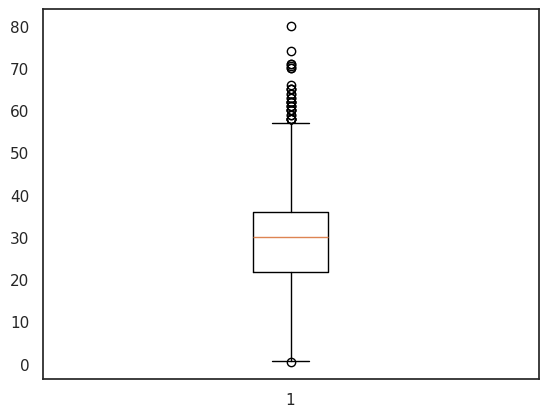

In [205]:
# Age, Fare 값 BoxPlot으로 확인
plt.boxplot([df_train['Age']])


([<matplotlib.axis.XTick at 0x7b68e91b2ff0>,
 [Text(1, 0, 'Age'), Text(2, 0, 'Fare')])

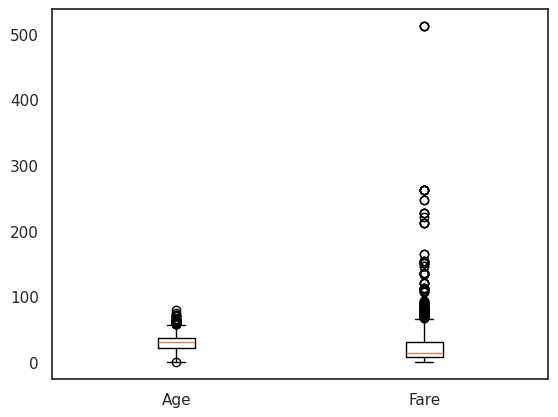

In [200]:
# Age, Fare 값 BoxPlot으로 확인
plt.boxplot([df_train['Age'], df_train['Fare']])
plt.xticks([1, 2],['Age', 'Fare'])

두 Feature 모두 통계상의 이상치를 가지고 있으나, ‘Age‘의 경우 인간의 수명 범위내 임을 알 수 있어서,  ‘Fare’ 데이터에 대해서만 더 자세히 살펴본다. ‘Fare’는  티켓운임을 감안하여 ‘Pclass’와 함께 살펴본다.


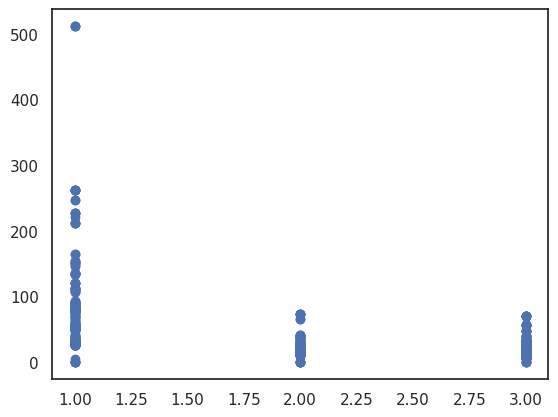

In [208]:
# Fare 데이터 자세히 들여다보기 - Pclass별로
plt.scatter(df_train['Pclass'], df_train['Fare'])

In [209]:
# Fare 데이터 자세히 들여다보기 - 실제 샘플 확인
df_train.sort_values(by=['Fare'], ascending=False).head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_isna,Title
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,C,0,Mr
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,C,0,Miss
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,C,0,Mr
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,S,0,Miss
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,S,0,Mr


실제 티켓의 운임으로 보인다. 본 실습에 주어진 데이터에는 이상치가 없다고 판단, 다음 단계로 넘어간다.

### 정규화

연속형 실수 값을 가지는 ‘Age‘, ‘Fare’'에 대해서만 정규화를 적용해본다. 정규화의 경우, 학습 데이터 기준으로 생성한 Scaler를 테스트 데이터에 그대로 적용해야 하는 것에 주의해야 한다.

스케일러 1) 값의 최고와 최저를 맞춤 2) 평균, 표준편차로 맞춤 (standard scalaer)
x축과 y축 수직

In [ ]:
from sklearn import preprocessing

# Age, Fare에 대해 z-score 정규화
columns_to_scale = ['Age', 'Fare']
#scaler_train = preprocessing.MinMaxScaler()
scaler_train = preprocessing.StandardScaler()
# 나중에 테스트 데이터에 적용하기 위하여 fit 단계와 transform 단계를 분리한다.
scaler_train = scaler_train.fit(df_train[columns_to_scale])
df_train[columns_to_scale] = scaler_train.transform(df_train[columns_to_scale])
df_train

### 인코딩

String 형태의 명목형 변수는 많은 ML 알고리즘에서 적절하게 계산되지 않는다. 명목형 변수인 ‘Sex’와 ‘Embarked’에 대해 One-Hot 인코딩을 하여 수치형 벡터로 변환한다.


In [ ]:
# Sex(성별), Embarked(배에 탑승한 위치) 데이터 인코딩
df_train = pd.get_dummies(df_train, columns = ['Sex', 'Embarked'])
df_train.iloc[:, -5:]

마지막으로 Cardinality가 높은 ‘Name’, ‘Ticket’에 대해 Feature로 활용할 수 있을지 살펴보자.

In [ ]:
# Ticket 데이터 살펴보기
df_train['Ticket'].sort_values().values[-10:]

In [ ]:
# Name 데이터 살펴보기
df_train['Name'].sort_values().values[:10]

‘Ticket’ 데이터는 Cardinality가 너무 높고, 분석에 의미 있게 사용될 것 같지 않아 대상에서 제외하도록 한다. Name의 경우도 분석 대상에서 제외하는 것을 고려해볼 수 있으나, 데이터를 최대한 활용하는 차원에서 Name에 포함된 호칭 (OOO.) 부분을 추출해서 활용도를 확인해보자.

In [ ]:
# Name에 포함된 호칭 추출하여 확인
# 정규표현식은 학습범위를 벗어나므로 결과만을 참고한다.
df_train['Name'].str.extract("([A-Za-z]+)\.").value_counts(dropna=False)

‘Mr’, “Miss’ ‘Mrs’ 등의 호칭은 ‘Sex(성별)’ 필드에서도 충분히 얻을 수 있는 정보이므로 직업/사회적 지위를 나타내는
호칭을 포함하는 경우 ‘Name_has_title’이라는 이름으로 Flag를 생성해보자

In [ ]:
# 이름에 'Master', 'Dr', 'Rev(목사)', 'Major', 'Col(대령)', 'Capt', 'Jonkheer(귀족)', 'Don', 'Countess(백작)', 'Sir＇ 포함 여부를 Flag화 한다.
df_train['Name_has_title'] = df_train['Name'].str.contains('Master|Dr|Rev|Major|Col|Capt|Jonkheer|Don|Countess|Sir').astype(int)

In [ ]:
df_train['Name_has_title'].value_counts()

In [ ]:
# Name, Ticket 필드 분석에서 제외
df_train = df_train.drop(columns=['Ticket', 'Name'])

In [ ]:
df_train['Name_has_title'].value_counts()

## 텍스트 분석

분석 대상이 비정형/반정형 텍스트 데이터의 경우
- 데이터 스토어에서 필요한 텍스트 데이터를 추출
- 어휘/구문 분석, 감성 분석, 토픽 분석, 오피니언 분석, 소셜 네트워크 분석 등을 실시
- 텍스트 분석 결과는 모델링 태스크와 연동하여 프로젝트 목적에 부합하는 최종 모델을 구축한다.


본 프로젝트에서는  전처리 단계에서 Name 필드로부터 의미 있는 Feature를 추출한 정도 이외에는) 텍스트 마이닝이 필요할 정도의 비정형 데이터를 포함하지 않아 텍스트 분석 단계를 거치지 않음


## 탐색적 분석

탐색적 분석 단계 빅데이터 분석 방법론
- 다양한 관점으로 평균, 분산 등 기초 통계량을 산출하여 데이터의 분포와 변수 간의 관계 등 데이터 자체의 특성과 통계적 특성을 파악한다.
- 시각화를 탐색적 데이터 분석을 위한 도구로 활용하여 데이터의 가독성을 높임


### 산포도 분석

개별 Feature에 대한 데이터 탐색은 전처리 과정에서 충분히 살펴보았으므로 여기에서는 관심대상인 ‘Survived’ 값과의 관계를 탐색해본다.

In [ ]:
# Pclass에 따른 Survived(사망자/생존자) 분포
hist1 = df_train[df_train['Survived']==0]['Pclass']
hist2 = df_train[df_train['Survived']==1]['Pclass']
plt.hist([hist1, hist2], label=['Dead', 'Alive'], alpha=0.5)
plt.legend(loc=0)

In [ ]:
# Pclass에 따른 Survived(사망자/생존자) 분포
hist1 = df_train[(df_train['Survived']==0) & (df_train['Sex_female'])]['Age']
hist2 = df_train[(df_train['Survived']==1) & (df_train['Sex_female'])]['Age']
plt.hist(hist1, label='Dead', bins=25, alpha=0.5)
plt.hist(hist2, label='Alive', bins=25, alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.legend(loc=0)

### 상관관계 분석

In [ ]:
# 상관관계 계산
cols_to_corr = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Name_has_title']
df_train[cols_to_corr].corr().round(2)

In [ ]:
# 상관관계 시각화
cols_to_corr = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Name_has_title']
fig, ax = plt.subplots(1, 1)
c = ax.pcolor(df_train[cols_to_corr].corr().round(2), cmap='RdBu_r')
fig.colorbar(c, ax=ax)
plt.xticks(np.arange(0.5, len(cols_to_corr), 1), cols_to_corr)
plt.yticks(np.arange(0.5, len(cols_to_corr), 1), cols_to_corr)

상관관계가 높은 변수의 경우 모델링 단계에 있어서 차원축소 등에 사용 가능
본 데이터는 ‘Fare’와 ‘Pclass’가 약한 음의 상관관계 -0.55, ‘SibSp’와 ‘Parch’가 약한 양의 상관관계 0.41 만이 있다.

## 모델링

모델링 단계 빅데이터 분석 방법론
- 모델의 과적합 방지와 일반화를 위해서 분석용 데이터셋을 훈련용 데이터와 모델의 검증 테스트하기 위한 데이터로 분할
- (가설 설정을 통하여 통계 모델을 만들거나) 기계 학습을 이용한 데이터의 분류, - 예측, 군집 등의 모델을 생성
- 필요 시 비정형 데이터 분석결과를 활용하여 통합 모델링 수행


### 전처리 함수 refactoring

- 훈련용 데이터에 적용한 전처리 방법들을, 테스트 데이터에도 적용해야 한다는 개념을 학습하기 위해 임의로 함수를 작성함
- scikit-learn의 pipeline이나 PyTorch와 같은 전용 프레임워크를 사용 할 수 있음

In [ ]:
# 전처리 함수 refactoring
def part5_preprocessing(df_orig, mode='train', replace_embarked=None, title_age_mean = None, title_list=None,  replace_age=None, scaler=None):
    df = df_orig.copy()

    # 결측치 처리
    df.fillna(0, inplace=True)
    df['Cabin'] = df['Cabin'].replace(0,"Null")

    if mode == 'train':
      b = df[['Cabin']].to_numpy()

      c = []

      for i in range(len(b)):
          c.append(b[i][0][0])
          i+=1

      df['Cabin'] = c
    else:
      b1 = df[['Cabin']].to_numpy()
      c1 = []
      for j in range(len(b1)):
          c1.append(b1[j][0][0])
          j+=1

      df['Cabin'] = c1

    df['Sex']=df['Sex'].replace('male',1)
    df['Sex']=df['Sex'].replace('female',0)
    df['Cabin']=df['Cabin'].replace('A',1)
    df['Cabin']=df['Cabin'].replace('B',2)
    df['Cabin']=df['Cabin'].replace('C',3)
    df['Cabin']=df['Cabin'].replace('D',4)
    df['Cabin']=df['Cabin'].replace('E',5)
    df['Cabin']=df['Cabin'].replace('F',6)
    df['Cabin']=df['Cabin'].replace('G',7)
    df['Cabin']=df['Cabin'].replace('T',8)
    df['Cabin']=df['Cabin'].replace('N',9)
    df['Embarked'] = df['Embarked'].replace('C',1)
    df['Embarked'] = df['Embarked'].replace('Q',2)
    df['Embarked'] = df['Embarked'].replace('S',3)

    return df

In [ ]:
# 전처리 함수 refactoring
def part5_preprocessing(df_orig, mode='train', replace_embarked=None, title_age_mean = None, title_list=None,  replace_age=None, scaler=None):
    df = df_orig.copy()
    # 결측치 처리 (훈련 데이터 상에서 파악한 최빈도값/평균값 공통 사용)
    df['Title'] = df['Name'].apply(lambda x:x.split(',')[1].split('.')[0].strip())

    if mode == 'train':
        replace_embarked = df['Embarked'].value_counts(dropna=False).idxmax()

        title_list = df['Title'].unique()
        #print(df['Title'].isnull().value_counts())
        title_age_mean = df.groupby('Title')['Age'].mean().to_dict()
        # title_map = {title: idx for idx, title in enumerate(sorted(title_list))}
        replace_age = df['Age'].mean().round(2)


    df['Age_isna'] = df['Age'].isna().astype(int)
    df['Embarked_isna'] = df['Embarked'].isna().astype(int)
    df['Cabin_isna'] = df['Cabin'].isna().astype(int)

    df['Embarked'] = df['Embarked'].fillna(replace_embarked)
    title_age_replace_value = df['Title'].map(title_age_mean)
    df['Age'] = df['Age'].fillna(title_age_replace_value)
    # df['Age'] = df['Age'].fillna(replace_age)

    # 이상값 처리 - 없음

    # 데이터 정규화 (훈련 데이터 상에서 학습된 scaler 공통 사용)
    if mode == 'train':
       scaler = preprocessing.StandardScaler()
       scaler = scaler.fit(df[['Age', 'Fare']])
    df[['Age', 'Fare']] = scaler.transform(df[['Age','Fare']])

    # 데이터 인코딩
    df['Title'] = pd.Categorical(df['Title'], categories=title_list)
    df = pd.get_dummies(df, columns = ['Sex', 'Embarked', 'Title'])
    # df['Name_has_title'] = df['Name'].str.contains('Master|Dr|Rev|Major|Col|Capt|Jonkheer|Don|Countess|Sir').astype(int)

    # 전처리에 사용된 원본 필드, 분석에 불필요한 필드를 제외시킨다.
    df = df.drop(columns=['Name', 'Ticket','Cabin'])

    return df, replace_embarked, title_age_mean, title_list, replace_age, scaler

In [ ]:
# 전처리 함수 refactoring
def part5_preprocessing_v6(df_orig, mode='train', replace_embarked=None, title_age_mean = None, title_list=None,  replace_age=None, scaler=None):
    df = df_orig.copy()
    # 결측치 처리 (훈련 데이터 상에서 파악한 최빈도값/평균값 공통 사용)
    df['Title'] = df['Name'].apply(lambda x:x.split(',')[1].split('.')[0].strip())

    if mode == 'train':
        replace_embarked = df['Embarked'].value_counts(dropna=False).idxmax()

        title_list = df['Title'].unique()
        #print(df['Title'].isnull().value_counts())
        title_age_mean = df.groupby('Title')['Age'].mean().to_dict()
        # title_map = {title: idx for idx, title in enumerate(sorted(title_list))}
        replace_age = df['Age'].mean().round(2)


    df['Age_isna'] = df['Age'].isna().astype(int)
    df['Embarked_isna'] = df['Embarked'].isna().astype(int)
    df['Cabin_isna'] = df['Cabin'].isna().astype(int)

    #결측치 처리
    #df['Embarked'] = df['Embarked'].fillna(replace_embarked)
    #title_age_replace_value = df['Title'].map(title_age_mean)
    #df['Age'] = df['Age'].fillna(title_age_replace_value)
    df['Age'] = df['Age'].fillna(replace_age)
    df = df.dropna(axis=0, subset=['Embarked'])
    df.fillna(0, inplace=True)


    # 이상값 처리 - 없음

    # 데이터 정규화 (훈련 데이터 상에서 학습된 scaler 공통 사용)
    if mode == 'train':
       scaler = preprocessing.StandardScaler()
       scaler = scaler.fit(df[['Age', 'Fare']])
    df[['Age', 'Fare']] = scaler.transform(df[['Age','Fare']])

    # 범주형 데이터 타입 변경
    df['Sex'] = df['Sex'].astype('category')
    df['Embarked'] = df['Embarked'].astype('category')

    # 데이터 인코딩
    # df['Title'] = pd.Categorical(df['Title'], categories=title_list)
    # df = pd.get_dummies(df, columns = ['Sex', 'Embarked', 'Title'])
    # df['Name_has_title'] = df['Name'].str.contains('Master|Dr|Rev|Major|Col|Capt|Jonkheer|Don|Countess|Sir').astype(int)
    df = pd.get_dummies(df, columns = ['Sex', 'Embarked', 'Pclass'])


    # 전처리에 사용된 원본 필드, 분석에 불필요한 필드를 제외시킨다.
    # df = df.drop(columns=['Name', 'Ticket','Cabin'])
    df = df.drop(columns=['Name', 'Ticket','Cabin', 'Title'])

    return df, replace_embarked, title_age_mean, title_list, replace_age, scaler

### 훈련용 데이터 전처리 (일괄)

공통 함수화 한 커스텀 전처리 함수를 통해 학습 데이터와 테스트 데이터에 동일한 기준으로 전처리를 수행한다.

In [ ]:
# 다항회귀로 훈련 후 랜덤 포레스트
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import PolynomialFeatures


df_train = pd.read_csv(colab_path + 'titanic/titanic_train.csv')
train_y = df_train['Survived']
df_train = df_train.drop(df_train.columns[[0,1,3,8]], axis=1)
df_train = part5_preprocessing(df_train, 'train')
df_test = pd.read_csv(colab_path + '/titanic/titanic_test.csv')
df_test = df_test.drop(df_test.columns[[0,2,7]], axis=1)
df_test = part5_preprocessing(df_test, 'test')
df_train
test_y = pd.read_csv(colab_path + '/titanic/titanic_gender_submission.csv')
test_y = test_y['Survived']

poly = PolynomialFeatures(degree=2, include_bias=False)
poly.fit(df_train, df_test)
train_poly = poly.transform(df_train)
test_poly = poly.transform(df_test)

# rf = RandomForestClassifier(n_estimators=100, max_depth = 3, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(train_poly, train_y)
print(rf.score(train_poly, train_y))
pred = rf.predict(test_poly)
print(rf.score(test_poly, test_y))

# test_poly = poly.transform(test_data)
# rf.fit(test_poly, test_target)
# print(rf.score(test_poly, test_target))


In [ ]:
# 학습 데이터 전처리 (일괄 적용)
df_train = pd.read_csv(colab_path + 'titanic/titanic_train.csv')
df_train, replace_embarked, title_age_mean, title_list, replace_age, scaler = part5_preprocessing_v6(df_train, 'train')

### 훈련/테스트 데이터 분할

- 모델 학습 이전에 모델 검증을 위한 테스트 데이터를 별도 분리하고 최종 검증에 사용
- 본 실습에서는 사전에 이미 분리하여 본 과정은 생략함.


### Feature (X), Label (y) 분리

- 지도학습의 경우 학습용 데이터가 Label을 포함하고 있어야 한다.
- Label이 어떤 필드인지를 지정해주기 위해 데이터에서 Feature와 Label을 분리


In [ ]:
# Feature(X), Label(y) 분리
target_col = 'Survived'
y = df_train[target_col]
X = df_train.drop(columns=[target_col])

### 훈련/평가용 데이터 분할

모델을 평가하기 위한 평가용 데이터셋을 분할한다.

In [ ]:
from sklearn.model_selection import train_test_split

# 훈련용/평가용 데이터 분할
train_X, val_X, train_y, val_y = train_test_split(X, y, test_size=0.3, random_state=42 )
train_X.columns

지도학습-분류를 위한 모델을 3개 선택하여 학습시키고 가장 좋은 성능을 보이는 모델을 최종 선택한다. 3가지 모델은 Logistic Regression, SVM, Decision Tree로 한다.


### 모델 #1 – Logistic Regression

로지스틱 회귀는 로지스틱 함수를 통해 데이터가 어떤 범주에 속할 확률을 0에서 1 사이 값으로 예측하고, 그 확률에 따라 가능성이 더 높은 범주에 속하는 것으로 분류하는 지도학습 모델
Scikit-learn에서 제공하는 LogisticRegression 모듈을 사용할 경우 주요 파라미터는 다음과 같다.
학습시 설정 할 주요 파라미터는 penalty(규제) 종류와 그 강도(C) 임


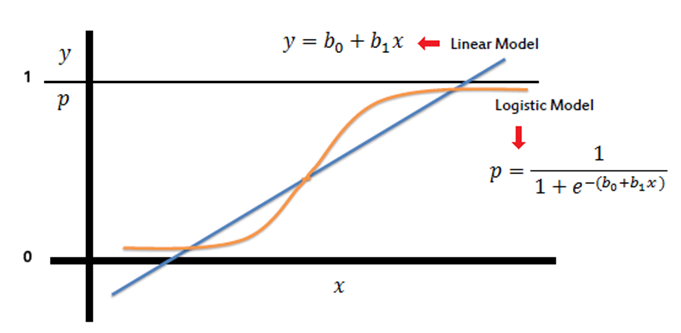

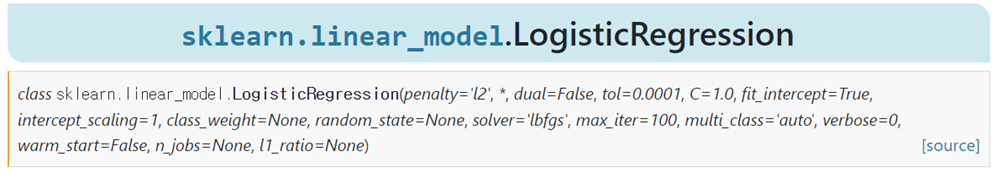

In [ ]:
# 모델 학습 및 예측
from sklearn.linear_model import LogisticRegression
model1 = LogisticRegression(C=20, max_iter=1000, random_state=42)
model1.fit(train_X, train_y)

In [ ]:
print(train_X)
print(train_y)

In [ ]:
train_X

In [ ]:
train_X = train_X.astype(int)
train_y = train_y.astype(int)
logm1 = sm.GLM(train_y,(sm.add_constant(train_X)), family = sm.families.Binomial()) # 로지스틱 회귀 모델 생성
logm1.fit().summary() # 모델 요약

In [ ]:
scaler

In [ ]:
# 테스트 데이터 전처리
# 테스트 데이터 전처리
df_test = pd.read_csv(colab_path + '/titanic/titanic_test.csv')
df_test, replace_embarked, title_age_mean, title_list, replace_age, scaler = part5_preprocessing_v6(df_test, 'test', replace_embarked, title_age_mean, title_list, replace_age, scaler)
test_X = df_test.astype(int)
test_X2 = test_X.drop(['Embarked_Q','Pclass_2'], axis = 1) # 불필요한 데이터 삭제
train_X2 = train_X.drop(['Embarked_Q','Pclass_2'],axis = 1) # 불필요한 데이터 삭제
logm2 = sm.GLM(train_y,(sm.add_constant(train_X2)), family = sm.families.Binomial()) # 로지스틱 회귀 모델 생성
logm2.fit().summary()

In [ ]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
from sklearn.feature_selection import RFE
rfe = RFE(logreg) # 변수 선택
rfe = rfe.fit(X,y)  # 변수 선택
print(rfe.support_) # 변수 선택 확인
print(rfe.ranking_) # 변수 선택 확인
col = ['Sex_male','Pclass_3', 'Fare','Age','Embarked_S','Parch'] # 변수 선택

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
logsk = LogisticRegression(C=1e9) # 로지스틱 회귀 모델 생성
logsk.fit(train_X, train_y) # 모델 생성

In [ ]:
logm4 = sm.GLM(train_y,(sm.add_constant(train_X)), family = sm.families.Binomial()) # 로지스틱 회귀 모델 생성
modres = logm4.fit() # 모델 생성
logm4.fit().summary()

In [ ]:
y_pred = logsk.predict_proba(test_X) # 예측
y_pred_df = pd.DataFrame(y_pred)
y_pred_1 = y_pred_df.iloc[:,[1]]
y_pred_1

In [ ]:
y_test_df = pd.DataFrame(test_y)
y_test_df

In [ ]:
y_test_df['PassengerId'] = y_test_df.index # 데이터 합치기
y_pred_1.reset_index(drop=True, inplace=True) # 데이터 합치기
y_test_df.reset_index(drop=True, inplace=True) # 데이터 합치기
y_pred_final = pd.concat([y_test_df,y_pred_1],axis=1) # 데이터 합치기
y_pred_final= y_pred_final.rename(columns={ 1 : 'Survived_Prob'}) # 데이터 합치기
y_pred_final = y_pred_final.reindex(['PassengerId','Survived','Survived_Prob'], axis=1) # 데이터 합치기
y_pred_final.head()

In [ ]:
y_pred_final['predicted'] = y_pred_final.Survived_Prob.map( lambda x: 1 if x > 0.5 else 0) # 예측값 생성

y_pred_final.head()

In [ ]:
from sklearn import metrics

In [ ]:
confusion = metrics.confusion_matrix( y_pred_final.Survived, y_pred_final.predicted ) # 혼동행렬 생성
confusion

In [ ]:
metrics.accuracy_score(y_pred_final.Survived, y_pred_final.predicted) # 정확도 확인

In [ ]:
def draw_roc( actual, probs ): # ROC 곡선 생성
    fpr, tpr, thresholds = metrics.roc_curve( actual, probs, drop_intermediate = False )
    auc_score = metrics.roc_auc_score( actual, probs )
    plt.figure(figsize=(6, 6))
    plt.plot( fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score )
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic example')
    plt.legend(loc="lower right")
    plt.show()

    return fpr, tpr, thresholds

In [ ]:
draw_roc(y_pred_final.Survived, y_pred_final.predicted) # ROC 곡선 확인
"{:2.2f}".format(metrics.roc_auc_score(y_pred_final.Survived, y_pred_final.Survived_Prob)) # AUC 확인

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(random_state=42) # PCA 생성
pca.fit(train_X) # PCA 생성
#pca.components_ # PCA 생성
pca.explained_variance_ratio_ # PCA 생성
var_cumu = np.cumsum(pca.explained_variance_ratio_) # PCA 생성

In [ ]:
fig = plt.figure(figsize=[12,8])
plt.vlines(x=2.5, ymax=1, ymin=0, colors="r", linestyles="--")
plt.hlines(y=0.8, xmax=15, xmin=0, colors="g", linestyles="--")
plt.plot(var_cumu)
plt.ylabel("Cumulative variance explained")
plt.show()

In [ ]:
from sklearn.decomposition import IncrementalPCA
pca_final = IncrementalPCA(n_components=6) # PCA 생성
df_train_pca = pca_final.fit_transform(train_X) # PCA 생성
corrmat = np.corrcoef(df_train_pca.transpose()) # PCA 생성
df_test_pca = pca_final.transform(test_X) # PCA 생성
df_test_pca.shape

In [ ]:
learner_pca = LogisticRegression() # 로지스틱 회귀 모델 생성
model_pca = learner_pca.fit(df_train_pca, train_y) # 로지스틱 회귀 모델 생성
pred_probs_test = model_pca.predict_proba(df_test_pca) # 예측
"{:2.2}".format(metrics.roc_auc_score(test_y, pred_probs_test[:,1])) # AUC 확인

In [ ]:
pca_again = PCA(0.9) # PCA 생성
df_train_pca2 = pca_again.fit_transform(train_X) # PCA 생성
learner_pca2 = LogisticRegression() # 로지스틱 회귀 모델 생성
model_pca2 = learner_pca2.fit(df_train_pca2, train_y) # 로지스틱 회귀 모델 생성
df_test_pca2 = pca_again.transform(test_X) # PCA 생성
pred_probs_test2 = model_pca2.predict_proba(df_test_pca2)[:,1] # 예측
"{:2.2}".format(metrics.roc_auc_score(test_y, pred_probs_test2)) # AUC 확인

In [ ]:
df_test_y = pd.read_csv(colab_path + '/titanic/titanic_gender_submission.csv')
df_test_y = df_test_y['Survived']
df_test['Survived'] = df_test_y['Survived'].apply(str) # 데이터 타입 변경
df_test['Pclass'] = df_test['Pclass'].apply(str) # 데이터 타입 변경

### 모델 #2 – SVM 선택

SVM(Support Vector Machine, 서포트 벡터 머신)은 결정 경계(Decision Boundary), 즉 분류를 위한 기준 선(평면)을 정의하고자 할 때 그 중 가장 큰 폭을 가지는 경계를 찾는 알고리즘
Scikit-learn에서 제공하는 SVC 모듈을 사용할 경우 주요 파라미터 중 학습 시 결정이 필요한 파라미터는 kernel 등이 있다.

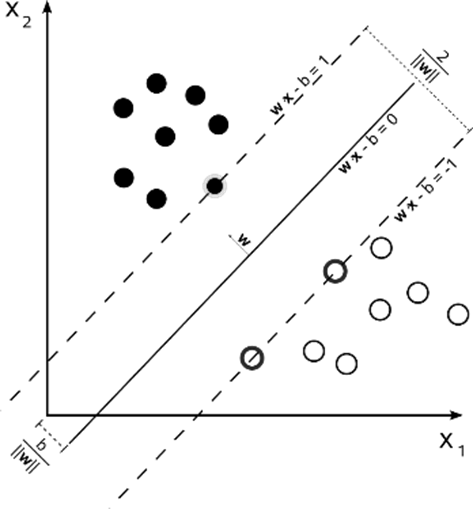

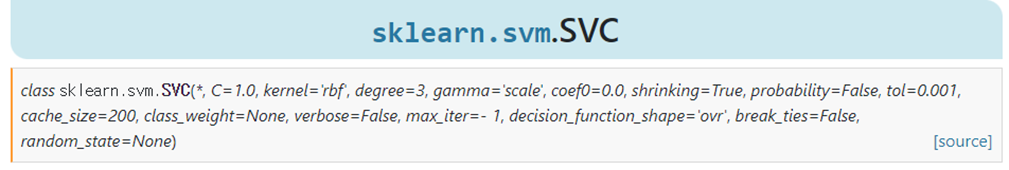

In [ ]:
# 모델 학습 및 예측
from sklearn.svm import SVC
model2 = SVC(kernel = 'linear', probability=True, random_state=42)
model2.fit(train_X, train_y)

### 모델 #3 – Random Forest 선택

- Random Forest는 의사결정나무의 앙상블 버전 알고리즘
- sklearn.ensemble.RandomForestClassifier를 통해 구현할 수 있으며, Random Forest 알고리즘의 주의사항인 과적합을 제어하기 위해 max_depth, min_samples_split 파라미터 최적화 필요


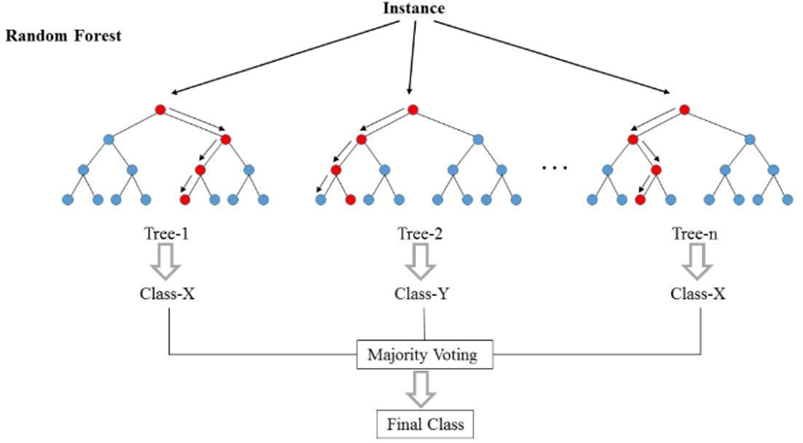

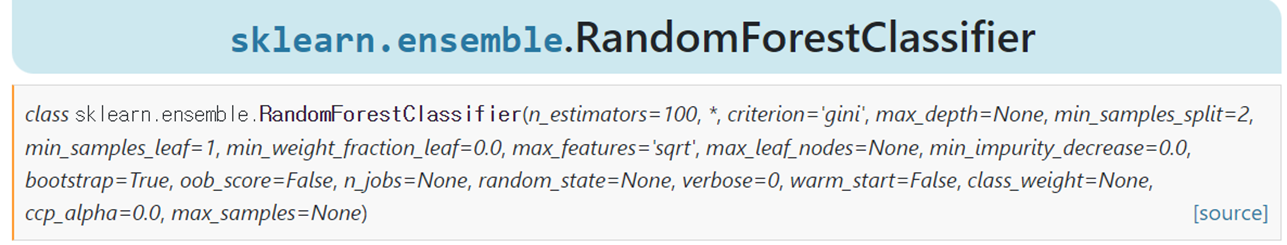

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html


In [ ]:
# 모델 학습
from sklearn.ensemble import RandomForestClassifier
model3 = RandomForestClassifier(n_estimators=16, max_depth = 5, random_state=42)
model3.fit(train_X, train_y)

### XGBoost 사용해보자

In [ ]:
from xgboost import XGBClassifier

model4 = XGBClassifier(n_estimators=16, max_depth = 4, random_state=42)
model4.fit(train_X, train_y)

## 모델 평가 및 검증

모델 평가 및 검증 단계 빅데이터 분석 방법론
- 프로젝트 정의서의 평가 기준에 따라 모델의 완성도를 평가
- 데이터 분석 목적 및 데이터셋 특성에 따라 모델 평가 방법은 다양
- 모델 훈련 및 평가에 활용된 데이터가 아닌 별도의 데이터 (운영용 데이터) 를 확보하여 모델의 객관성과 실무 적용성을 검증
- 요구되는 성능 목표에 미달하는 경우 모델 튜닝 작업을 수행


### 모델 #1 – Logistic Regression 평가 (Validation 데이터 기준)

In [ ]:
# 모델 평가
print(model1.score(train_X, train_y))  # accuracy
print(model1.score(val_X, val_y))

### 모델 #2 – SVM (Validation 데이터 기준)

In [ ]:
# 모델 평가
print(model2.score(train_X, train_y))  # accuracy
print(model2.score(val_X, val_y))

### 모델 #3 – Random Forest (Validation 데이터 기준)

In [ ]:
# 모델 평가
print(model3.score(train_X, train_y))  # accuracy
print(model3.score(val_X, val_y))

### 모델 #4 - XGBoost

In [ ]:
# 모델 평가
print(model4.score(train_X, train_y))  # accuracy
print(model4.score(val_X, val_y))

### 모델 4종 성능 비교 (AUC Score)

In [ ]:
# AUC Score
from sklearn.metrics import roc_auc_score
print('AUC value (Logistic Regression): {}'.format(roc_auc_score(val_y, model1.predict(val_X))))
print('AUC value (SVM): {}'.format(roc_auc_score(val_y, model2.predict(val_X))))
print('AUC value (RandomForest): {}'.format(roc_auc_score(val_y, model3.predict(val_X))))
print('AUC value (XGBoost): {}'.format(roc_auc_score(val_y, model4.predict(val_X))))

### 모델 4종 성능 비교 (ROC Curve Plotting)

In [ ]:
# ROC Curve 플롯팅
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(val_y, model1.predict_proba(val_X)[:,1])
plt.plot([0,1], [0,1], "k--", "r+") #0.5 기준선
plt.plot(fpr, tpr, label='Logistic Regression')
fpr2, tpr2, thresholds2 = roc_curve(val_y, model2.predict_proba(val_X)[:,1])
plt.plot(fpr2, tpr2, label='SVM')
fpr3, tpr3, thresholds3 = roc_curve(val_y, model3.predict_proba(val_X)[:,1])
plt.plot(fpr3, tpr3, label='RandomForest')
fpr4, tpr4, thresholds4 = roc_curve(val_y, model4.predict_proba(val_X)[:,1])
plt.plot(fpr4, tpr4, label='XGBoost')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend(loc=0)

## 모델 적용 및 운영방안 수립

모델 적용및 운영방안 수립 단계 빅데이터 분석 방법론
- 모델을 운영시스템에 적용하는데 필요한 모델에 대한 알고리즘 설명서 작성
- 모델의 안정적 운영을 모니터링하는 방안을 수립


### 모델 저장

- 실제 운영환경에서는 모델을 학습하는 시스템과 실시간 운영 시스템이 분리된 경우가 많다.
- 학습된 모델을 버전 관리하고 운영시스템에 업데이트 하는 관리가 필요
- pickle 형태로 저장하고 예측이 필요한 시점에 해당 모델을 로드해서 이용 예 설명

In [ ]:
import pickle
# 모델 저장
# AUC Score 기준 가장 성능이 좋았던 Logistic Regression 모델을 저장한다.
with open(colab_path + 'titanic/saved_model4.pickle','wb') as fw:
    pickle.dump(model4, fw)

### 모델 로드

In [ ]:
# 모델 로드
with open(colab_path + 'titanic/saved_model4.pickle','rb') as f:
    xgmodel = pickle.load(f)

In [ ]:
# 모델 평가
print(xgmodel.score(train_X, train_y))  # accuracy
print(xgmodel.score(val_X, val_y))

### 테스트용 데이터 전처리

In [ ]:
# 테스트 데이터 전처리
df_test = pd.read_csv(colab_path + '/titanic/titanic_test.csv')

In [ ]:
# 테스트 데이터 전처리
df_test = pd.read_csv(colab_path + '/titanic/titanic_test.csv')
df_test, replace_embarked, title_age_mean, title_list, replace_age, scaler = part5_preprocessing(df_test, 'test', replace_embarked, title_age_mean, title_list, replace_age, scaler)
df_test

In [ ]:
# 결측치 처리
# 테스트 데이터 중 1건에 'Fare'에 대한 결측치가 존재하므로 결측치를 train 데이터의 평균값으로 대체한다.
replace_fare = df_train['Fare'].mean().round(2)
df_test['Fare'] = df_test['Fare'].fillna(replace_fare)
test_X = df_test.set_index('PassengerId')

### 생존률 예측 (테스트용 데이터)

In [ ]:
# 최종 생존율 예측
pred_y = xgmodel.predict(test_X)
df_pred_y = pd.DataFrame(pred_y, columns=['Survived'])
df_pred_y['PassengerId'] = df_test['PassengerId']
df_pred_y = df_pred_y.set_index('PassengerId')
df_pred_y.to_csv(colab_path + '/titanic/my_submission.csv')


In [ ]:
title_map

In [ ]:
# 최종 생존율 예측
pred_y = xgmodel.predict(test_X)
df_result = pd.DataFrame({'PassengerId':df_test['PassengerId'], 'Survived': pred_y})
df_pred_y.to_csv(colab_path + '/titanic/my_submission2.csv')